In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap



In [2]:
image = Image.open('modelo.jpg').convert('L')  # Reemplaza 'ruta_de_la_imagen.jpg' con la ruta de tu imagen
model = np.array(image)

In [3]:
model.shape

(4965, 2000)

In [4]:
np.unique(model)

array([  0,   1,   2,  14,  15,  16,  17,  29,  30,  31,  32,  46,  47,
        48,  62,  63,  64,  78,  79,  80,  94,  95,  96,  97, 110, 111,
       112, 126, 127, 128, 142, 143, 144, 158, 159, 160, 174, 175, 176,
       190, 191, 192, 206, 207, 208, 221, 222, 223, 224, 238, 239, 240,
       253, 254, 255], dtype=uint8)

In [5]:
num_rows, num_cols = model.shape
# Loop over the rows
for i in range(num_rows):
    # Loop over the columns within each row
    for j in range(num_cols):
        # Access the element at row i and column j
        if model[i, j] >= 125:
            model[i, j] = 0
        elif model[i, j] < 125:
            model[i, j] = 1
        

In [6]:
np.unique(model)

array([0, 1], dtype=uint8)

In [7]:
colors = ['yellow', 'grey']
values = [0, 1]
custom_cmap = ListedColormap(colors)


In [8]:
model[0, :]

array([1, 1, 1, ..., 1, 1, 1], dtype=uint8)

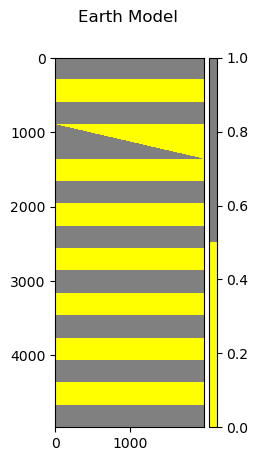

In [9]:
fig, ax = plt.subplots(1,1)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
im = ax.imshow(model, aspect=1, cmap=custom_cmap)
fig.colorbar(im, cax=cax, orientation='vertical')
fig.suptitle('Earth Model')
plt.show()

In [10]:
porosity_model = np.empty(model.shape)
for columna in range(len(model[0])):
    for fila in range(len(model)):
        
        if model[fila][columna]==1:
            porosity_model[fila][columna]= np.random.uniform(0.25,0.3)
        else:
            porosity_model[fila][columna] = np.random.uniform(0,0.01)

C:\Users\Msi\AppData\Local\Temp\ipykernel_15856\942548482.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


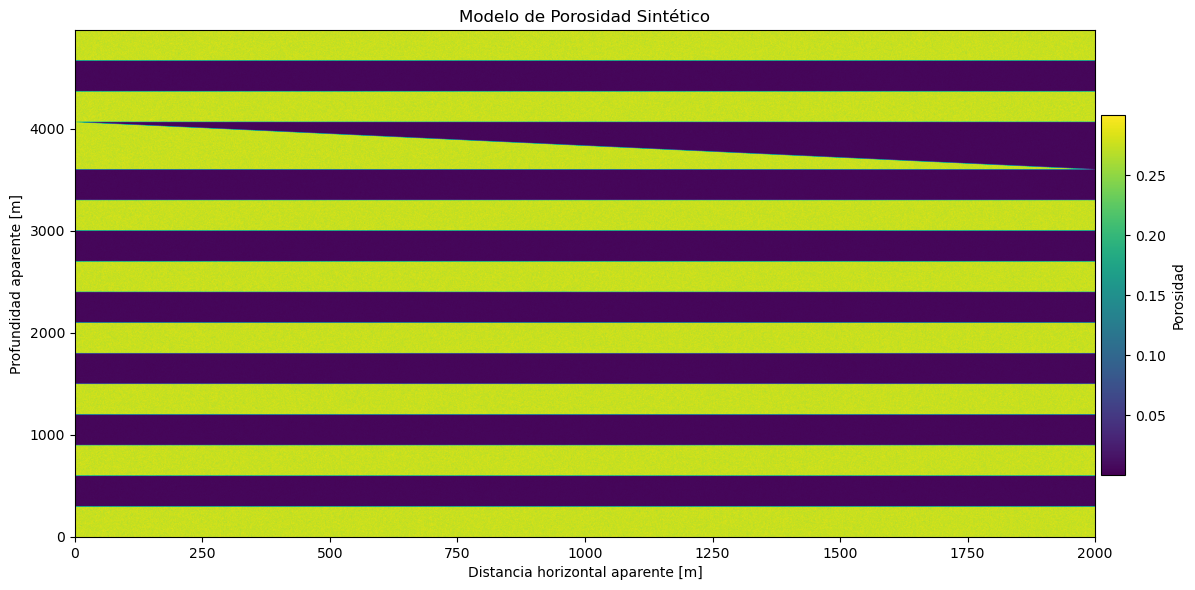

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(porosity_model, aspect=0.2, extent=[0, 2000, 0, 4965])
ax.set_ylabel('Profundidad aparente [m]')
ax.set_xlabel('Distancia horizontal aparente [m]')
ax.set_title('Modelo de Porosidad Sintético')

# Create a colorbar with the same height as the plot
cax = fig.add_axes([0.95, 0.2, 0.02, 0.6])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=porosity_model.min(), vmax=porosity_model.max()))
sm.set_array([])
plt.colorbar(sm, cax=cax, label='Porosidad', anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [12]:
velocity_model= 1/ ((porosity_model/4800) + ((1-porosity_model)/19000)) #Esta ecuacion va en ft/sec Wyllie 1956
density_model = 0.23 * np.power(velocity_model, 0.25) #Ecuacion de Gardner 1974 va en g/cc
imp =porosity_model * density_model
rc =  (imp[1:,:] - imp[:-1,:]) / (imp[1:,:] + imp[:-1,:])


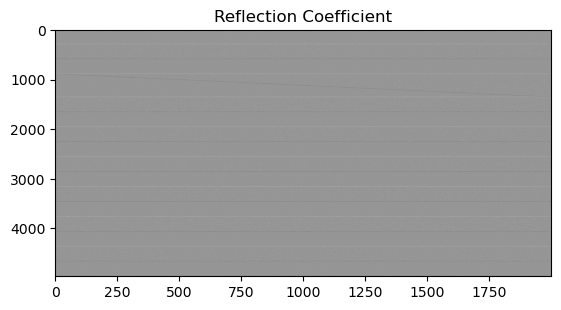

In [13]:

plt.imshow(rc, cmap='Greys', aspect=0.2)
plt.title('Reflection Coefficient')
plt.show()

# Ondicula de Ricker

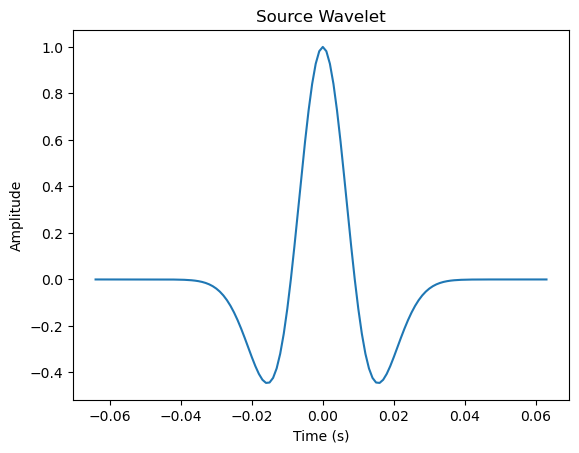

In [14]:
def ricker(f, length=0.128, dt=0.001):
    t = np.arange(-length/2, (length-dt)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y
 
f = 25 # A low wavelength of 25 Hz
t, w = ricker(f)
plt.plot(t,w)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Source Wavelet")
plt.show()

$S= R_c \ast  w(t) + N$

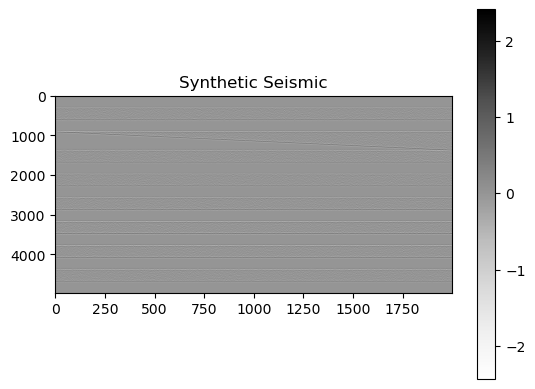

In [15]:
synth = np.apply_along_axis(lambda t: np.convolve(t, w, mode='same'),
                            axis=0,
                            arr=rc)

plt.imshow(synth, cmap="Greys", aspect=0.2)
plt.title('Synthetic Seismic')
plt.colorbar()
plt.show()

# Extracción de la ondícula

In [16]:
trace1 = np.random.randint(low=0, high=model.shape[1])
trace2 = np.random.randint(low=0, high=model.shape[1])

depth = range(0, model.shape[0]-1)

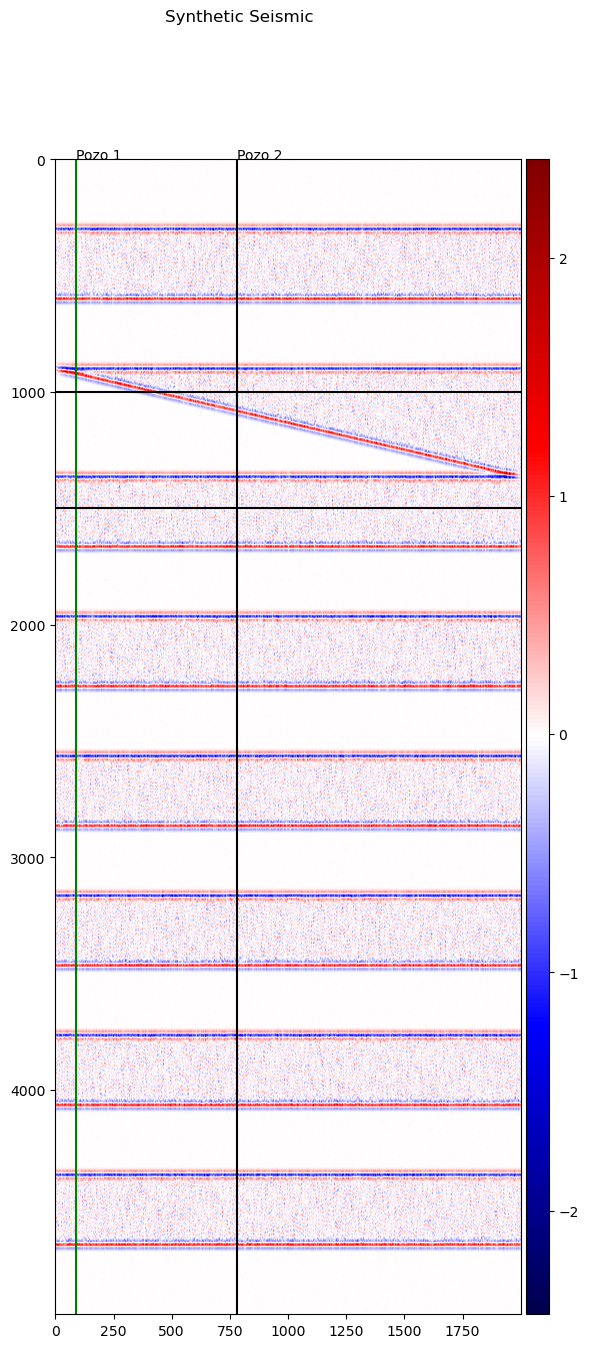

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(50, 15))
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
im = ax.imshow(synth, cmap="seismic")
ax.axvline(trace1, color='green')
ax.axvline(trace2, color='black')
ax.axhline(1000, color='black')
ax.axhline(1500, color='black')
fig.suptitle('Synthetic Seismic')
fig.colorbar(im, cax=cax, orientation='vertical')
ax.annotate('Pozo 1',xy=(trace1, 0))
ax.annotate('Pozo 2',xy=(trace2, 0))
plt.show()

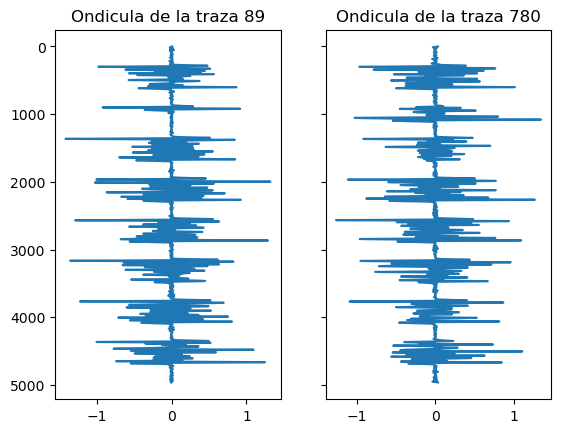

In [18]:
fig, ax  = plt.subplots(1, 2, sharey=True)
ax[0].plot(synth[:,trace1], depth)
ax[0].set_title(f'Ondicula de la traza {trace1}')
ax[0].invert_yaxis()

ax[1].plot(synth[:,trace2], depth)
ax[1].set_title(f'Ondicula de la traza {trace2}')

plt.show()

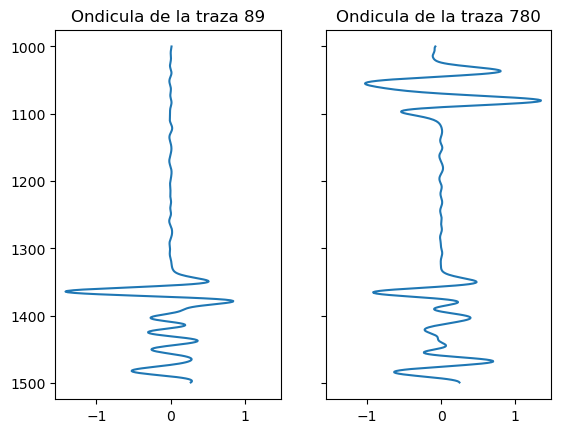

In [19]:
fig, ax  = plt.subplots(1, 2, sharey=True, sharex=True)
ax[0].plot(synth[1000:1500,trace1], depth[1000:1500])
ax[0].set_title(f'Ondicula de la traza {trace1}')
ax[0].invert_yaxis()

ax[1].plot(synth[1000:1500,trace2], depth[1000:1500])
ax[1].set_title(f'Ondicula de la traza {trace2}')

plt.show()